# Training


🏋️ 2. MULAI TRAINING...
🔄 1. MENYIAPKAN DATA...


More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13


   🔎 Ditemukan 95698 gambar asli. Memproses 500 sampel...


More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples 

   ✅ Data Latihan Siap!


Epoch 10/10: 100%|██████████| 23/23 [00:11<00:00,  2.06it/s, loss=0.00955]
C:\Users\Vulpolish\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (97244490 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


🎉 Training Selesai! Model disimpan ke 'my_model.pth'

✨ 3. MEMBERSIHKAN: Cloud.png


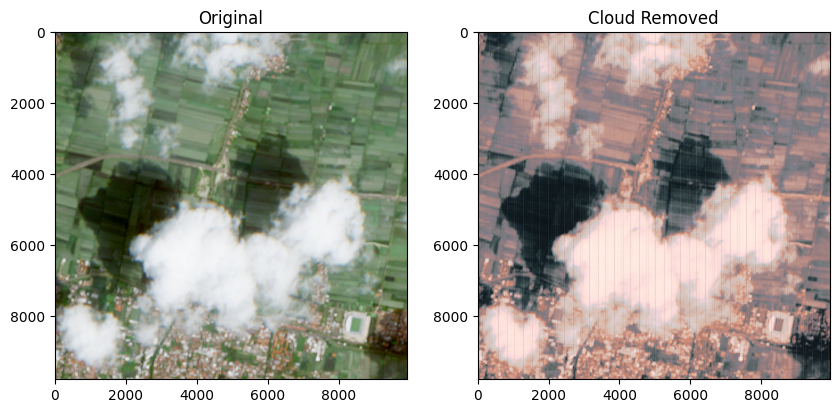

✅ Hasil disimpan sebagai 'Result_Final.png'


In [ ]:
import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from glob import glob

# ==========================================
# KONFIGURASI
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_EPOCHS = 10  # Cukup 10 epoch untuk tes awal
LR = 0.0002

# Folder Kerja (Kita buat folder baru biar bersih)
WORK_DIR = './Training_Data'
TARGET_DIR = os.path.join(WORK_DIR, 'targets') # Gambar Bersih
INPUT_DIR = os.path.join(WORK_DIR, 'inputs')   # Gambar Berawan

# ==========================================
# 1. PERSIAPAN DATA (AUTO-GENERATOR)
# ==========================================
def prepare_data():
    print("🔄 1. MENYIAPKAN DATA...")
    
    # Cek apakah data sudah siap
    if os.path.exists(TARGET_DIR) and len(os.listdir(TARGET_DIR)) > 100:
        print("   ✅ Data latih sudah ditemukan. Melewati proses generate.")
        return

    # Buat folder
    os.makedirs(TARGET_DIR, exist_ok=True)
    os.makedirs(INPUT_DIR, exist_ok=True)

    # Cari sumber gambar EuroSat
    source_patterns = ['./EuroSat/**/*.jpg', './EuroSat/**/*.tif', './EuroSat/*.jpg']
    source_files = []
    for pattern in source_patterns:
        source_files.extend(glob(pattern, recursive=True))
    
    if not source_files:
        print("   ❌ ERROR: Folder EuroSat tidak ditemukan! Pastikan folder 'EuroSat' ada.")
        # Buat data dummy biar kode tetap jalan (Darurat)
        print("   ⚠️ Membuat data DUMMY (Kotak warna-warni) karena EuroSat tidak ada.")
        for i in range(200):
            img = Image.fromarray(np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8))
            source_files.append(f"dummy_{i}")
            img.save(os.path.join(TARGET_DIR, f"{i}.jpg"))
            # Input dummy (noise)
            noise = np.random.randint(0, 255, (64, 64, 3), dtype=np.uint8)
            Image.fromarray(noise).save(os.path.join(INPUT_DIR, f"{i}.jpg"))
        return

    print(f"   🔎 Ditemukan {len(source_files)} gambar asli. Memproses 500 sampel...")
    
    # Ambil 500 gambar saja biar cepat
    random.shuffle(source_files)
    for i, src_path in enumerate(source_files[:500]):
        try:
            # 1. Simpan Target (Bersih)
            img = Image.open(src_path).convert('RGB').resize((64, 64))
            save_name = f"{i}.jpg"
            img.save(os.path.join(TARGET_DIR, save_name))

            # 2. Buat Input (Berawan Palsu)
            img_np = np.array(img).astype(float)
            # Buat noise putih (Awan)
            noise_mask = np.random.uniform(0, 1, (64, 64, 1))
            noise_mask = (noise_mask > 0.6).astype(float) # Blob kasar
            
            # Tempel awan
            cloudy = img_np * (1 - noise_mask) + 255 * noise_mask
            cloudy = np.clip(cloudy, 0, 255).astype(np.uint8)
            
            Image.fromarray(cloudy).save(os.path.join(INPUT_DIR, save_name))
        except Exception as e:
            pass
            
    print("   ✅ Data Latihan Siap!")

# ==========================================
# 2. DEFINISI MODEL (UNET)
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.conv4 = DoubleConv(128, 256)
        
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv5 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv6 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.conv7 = DoubleConv(64, 32)
        self.out = nn.Conv2d(32, 3, 1)

    def forward(self, x):
        c1 = self.conv1(x)
        c2 = self.conv2(self.pool1(c1))
        c3 = self.conv3(self.pool2(c2))
        bottleneck = self.conv4(self.pool3(c3))
        
        u1 = self.up1(bottleneck)
        u1 = torch.cat([u1, c3], dim=1)
        c5 = self.conv5(u1)
        
        u2 = self.up2(c5)
        u2 = torch.cat([u2, c2], dim=1)
        c6 = self.conv6(u2)
        
        u3 = self.up3(c6)
        u3 = torch.cat([u3, c1], dim=1)
        c7 = self.conv7(u3)
        return torch.sigmoid(self.out(c7))

# ==========================================
# 3. TRAINING LOOP
# ==========================================
class CloudDataset(Dataset):
    def __init__(self, root_input, root_target):
        self.files = sorted(os.listdir(root_input))
        self.root_input = root_input
        self.root_target = root_target
        self.transform = transforms.Compose([transforms.ToTensor()])

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        img_in = Image.open(os.path.join(self.root_input, name)).convert('RGB')
        img_ta = Image.open(os.path.join(self.root_target, name)).convert('RGB')
        return self.transform(img_in), self.transform(img_ta)

def train():
    print("\n🏋️ 2. MULAI TRAINING...")
    prepare_data() # Pastikan data ada dulu
    
    dataset = CloudDataset(INPUT_DIR, TARGET_DIR)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = UNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        epoch_loss = 0
        
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())
            
    torch.save(model.state_dict(), 'my_model.pth')
    print("🎉 Training Selesai! Model disimpan ke 'my_model.pth'")
    return model

# ==========================================
# 4. INFERENCE (PEMBERSIHAN AWAN)
# ==========================================
def clean_image(image_path, model):
    print(f"\n✨ 3. MEMBERSIHKAN: {image_path}")
    if not os.path.exists(image_path):
        print("   ❌ File gambar tidak ditemukan!")
        return
        
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    # Preprocess
    tf = transforms.ToTensor()
    tensor = tf(img).unsqueeze(0).to(DEVICE)
    
    # Sliding Window (Agar tidak pecah)
    model.eval()
    tile_size = 64
    canvas = torch.zeros_like(tensor)
    
    with torch.no_grad():
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                # Crop
                tile = tensor[:, :, y:y+tile_size, x:x+tile_size]
                # Pad jika di pinggir
                pad_h = tile_size - tile.shape[2]
                pad_w = tile_size - tile.shape[3]
                if pad_h > 0 or pad_w > 0:
                    tile = F.pad(tile, (0, pad_w, 0, pad_h))
                
                # Predict
                res = model(tile)
                
                # Crop padding
                if pad_h > 0 or pad_w > 0:
                    res = res[:, :, :tile_size-pad_h, :tile_size-pad_w]
                    
                canvas[:, :, y:y+tile_size, x:x+tile_size] = res

    result = canvas.squeeze(0).cpu().permute(1, 2, 0).numpy()
    
    # Simpan & Tampilkan
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(result); plt.title("Cloud Removed")
    plt.savefig('Result_Final.png')
    plt.show()
    print("✅ Hasil disimpan sebagai 'Result_Final.png'")
    

# ==========================================
# EKSEKUSI UTAMA
# ==========================================
if __name__ == "__main__":
    # 1. Train Model
    trained_model = train()
    
    # 2. Test ke Foto Kamu
    clean_image('Cloud.png', trained_model)

In [37]:
def train():
    print("\n🏋️ 2. MULAI TRAINING (MODE SERIUS)...")
    prepare_data() # Pastikan data ada
    
    dataset = CloudDataset(INPUT_DIR, TARGET_DIR)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    model = UNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.0002)
    
    # PERUBAHAN 1: Ganti MSELoss jadi L1Loss (Biar tidak abu-abu)
    criterion = nn.L1Loss() 
    
    # PERUBAHAN 2: Tambah durasi latihan
    # Kalau pakai GPU (T4/K80) ini cepat. Kalau CPU, mungkin butuh 30 menit.
    REAL_EPOCHS = 50 
    
    for epoch in range(REAL_EPOCHS):
        model.train()
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{REAL_EPOCHS}")
        epoch_loss = 0
        
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            
            out = model(x)
            loss = criterion(out, y) # Hitung error
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")
            
    torch.save(model.state_dict(), 'my_model.pth')
    print("🎉 Training Selesai! Model disimpan.")
    return model

In [38]:
from PIL import ImageEnhance

def enhance_result(image_array):
    # Ubah numpy array ke PIL Image
    img = Image.fromarray((image_array * 255).astype(np.uint8))
    
    # 1. Naikkan Kontras (Supaya tidak abu-abu)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(1.5) # Naikkan 50%
    
    # 2. Naikkan Warna (Supaya peta terlihat hijau/coklat)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(1.3)
    
    return np.array(img)

In [39]:
# --- IMPORTS TAMBAHAN (Pastikan ini ada) ---
from PIL import ImageEnhance
import matplotlib.pyplot as plt

# ==========================================
# FUNGSI 1: BOOSTER WARNA (Untuk hilangkan abu-abu)
# ==========================================
def enhance_result(image_array):
    # Ubah numpy array (0-1) ke PIL Image (0-255) agar bisa diedit
    # Kita kali 255 dulu lalu ubah ke integer
    img = Image.fromarray((image_array * 255).astype(np.uint8))
    
    # 1. Naikkan Kontras (Supaya tidak pudar/abu-abu)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(1.8) # Naikkan 80% (Bisa diubah angkanya)
    
    # 2. Naikkan Ketajaman Warna (Supaya peta terlihat hijau/coklat)
    enhancer = ImageEnhance.Color(img)
    img = enhancer.enhance(1.5) # Naikkan 50%
    
    return np.array(img)

# ==========================================
# FUNGSI 2: MEMBERSIHKAN AWAN (Updated)
# ==========================================
def clean_image(image_path, model):
    print(f"\n✨ 3. MEMBERSIHKAN: {image_path}")
    if not os.path.exists(image_path):
        print("   ❌ File gambar tidak ditemukan!")
        return
        
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    
    # Preprocess
    tf = transforms.ToTensor()
    tensor = tf(img).unsqueeze(0).to(DEVICE)
    
    # Sliding Window (Agar tidak pecah)
    model.eval()
    tile_size = 64
    canvas = torch.zeros_like(tensor)
    
    print("   Sedang memproses potongan gambar...")
    with torch.no_grad():
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                # Crop
                tile = tensor[:, :, y:y+tile_size, x:x+tile_size]
                # Pad jika di pinggir
                pad_h = tile_size - tile.shape[2]
                pad_w = tile_size - tile.shape[3]
                if pad_h > 0 or pad_w > 0:
                    tile = F.pad(tile, (0, pad_w, 0, pad_h))
                
                # Predict
                res = model(tile)
                
                # Crop padding
                if pad_h > 0 or pad_w > 0:
                    res = res[:, :, :tile_size-pad_h, :tile_size-pad_w]
                    
                canvas[:, :, y:y+tile_size, x:x+tile_size] = res

    # --- BAGIAN INI YANG DIPERBARUI ---
    
    # 1. Ambil hasil dari tensor ke numpy
    result = canvas.squeeze(0).cpu().permute(1, 2, 0).numpy()
    
    # 2. Safety Clip: Pastikan angkanya tidak minus atau lebih dari 1
    result = np.clip(result, 0, 1)
    
    # 3. PAKAI BOOSTER WARNA
    # Ini akan mengubah gambar abu-abu menjadi lebih tajam
    result_final = enhance_result(result)
    
    # 4. Tampilkan Perbandingan
    plt.figure(figsize=(12, 6))
    
    # Gambar Asli
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original (Berawan)")
    plt.axis('off')
    
    # Gambar Hasil AI + Booster
    plt.subplot(1, 2, 2)
    plt.imshow(result_final)
    plt.title("Hasil Bersih (Enhanced)")
    plt.axis('off')
    
    plt.show()
    
    # 5. Simpan
    Image.fromarray(result_final).save('Cloud_Removed_Final.png')
    print("✅ Hasil disimpan sebagai 'Cloud_Removed_Final.png'")


✨ 3. MEMBERSIHKAN: Cloud.png
   Sedang memproses potongan gambar...


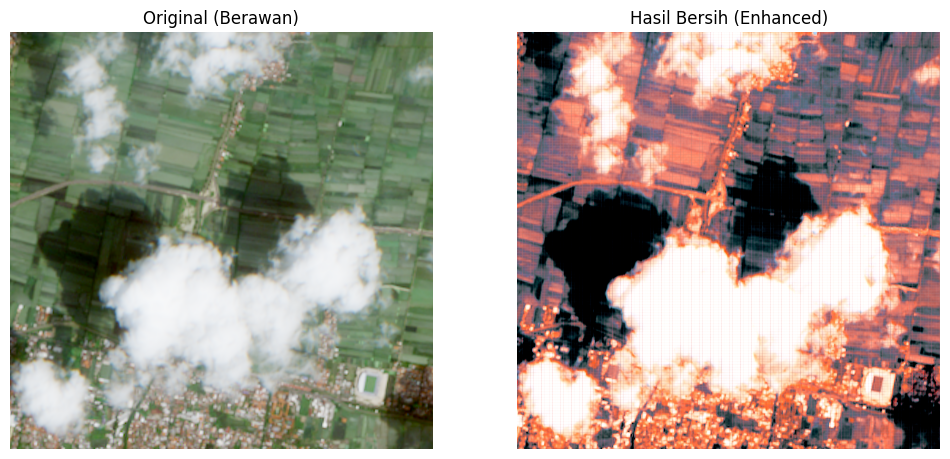

✅ Hasil disimpan sebagai 'Cloud_Removed_Final.png'


In [40]:
clean_image('Cloud.png', trained_model)


🏋️ 2. MULAI TRAINING...
🔄 1. MENYIAPKAN DATA (AWAN + BAYANGAN)...
   🔎 Memproses 600 sampel...
   ✅ Data Siap!


Epoch 40/40: 100%|██████████| 38/38 [00:19<00:00,  1.98it/s, loss=0.0637]



✨ 3. MEMBERSIHKAN: Cloud.png


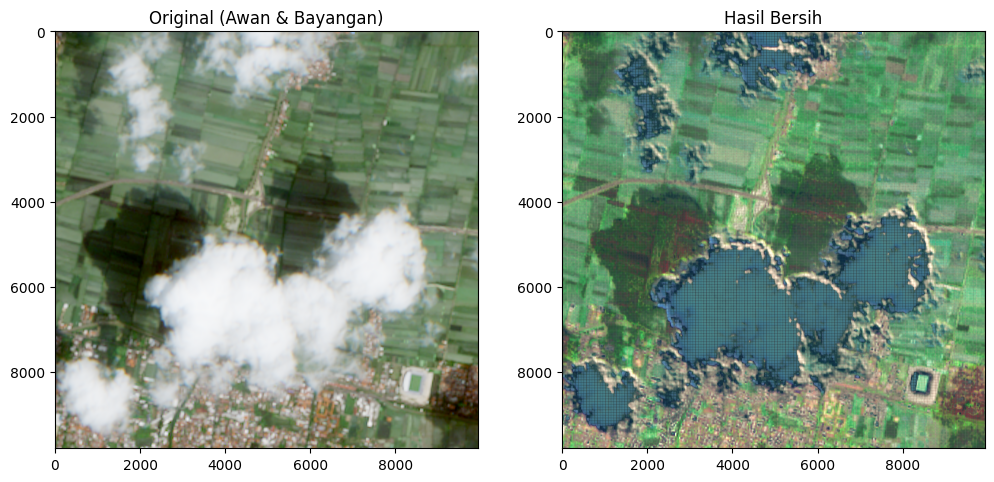

In [42]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance, ImageChops
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

# ==========================================
# KONFIGURASI
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_EPOCHS = 40  # Tambah dikit biar matang
LR = 0.0002

WORK_DIR = './Training_Final_Shadows'
TARGET_DIR = os.path.join(WORK_DIR, 'targets')
INPUT_DIR = os.path.join(WORK_DIR, 'inputs')

# ==========================================
# 1. GENERATOR AWAN + BAYANGAN (ADVANCED)
# ==========================================
def create_cloud_mask(w, h):
    """Membuat bentuk awan acak (blob)"""
    mask = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(mask)
    num_blobs = random.randint(3, 8)
    for _ in range(num_blobs):
        x = random.randint(0, w)
        y = random.randint(0, h)
        radius = random.randint(10, 35)
        # Gambar bentuk awan
        draw.ellipse((x-radius, y-radius, x+radius, y+radius), fill=255)
    
    # Blur agar pinggirannya halus (Cloudy look)
    mask = mask.filter(ImageFilter.GaussianBlur(radius=random.randint(4, 8)))
    return mask

def add_clouds_and_shadows(img_pil):
    """Menambahkan awan DAN bayangannya"""
    w, h = img_pil.size
    img_pil = img_pil.convert('RGB')
    
    # 1. Buat Masker Awan
    cloud_mask = create_cloud_mask(w, h)
    
    # 2. Buat Masker Bayangan (Geser awan ke kanan bawah)
    shadow_offset = (random.randint(3, 8), random.randint(3, 8))
    shadow_mask = ImageChops.offset(cloud_mask, shadow_offset[0], shadow_offset[1])
    
    # 3. Terapkan Bayangan (Gelapkan area bayangan)
    # Kita buat layer hitam
    shadow_layer = Image.new('RGB', (w, h), (0, 0, 0))
    # Gabungkan: Gambar Asli digelapkan di area shadow_mask
    # Semakin tinggi alpha, semakin gelap bayangannya
    img_with_shadow = Image.composite(shadow_layer, img_pil, shadow_mask)
    # Blend dengan gambar asli supaya bayangan transparan (tidak hitam total)
    img_pil = Image.blend(img_pil, img_with_shadow, 0.4) 
    
    # 4. Terapkan Awan (Putihkan area awan)
    cloud_layer = Image.new('RGB', (w, h), (255, 255, 255))
    # Blend awan dengan gambar yg sudah ada bayangannya
    final_img = Image.composite(cloud_layer, img_pil, cloud_mask)
    
    return final_img

def prepare_data():
    print("🔄 1. MENYIAPKAN DATA (AWAN + BAYANGAN)...")
    
    # Hapus data lama biar generator baru jalan
    if os.path.exists(WORK_DIR):
        import shutil
        shutil.rmtree(WORK_DIR)
        
    os.makedirs(TARGET_DIR, exist_ok=True)
    os.makedirs(INPUT_DIR, exist_ok=True)

    # Cari gambar EuroSat
    source_files = glob('./EuroSat/**/*.jpg', recursive=True) + glob('./EuroSat/*.jpg')
    
    if not source_files:
        print("   ⚠️ Mode Dummy (Tanpa EuroSat).")
        for i in range(300):
            img = Image.fromarray(np.random.randint(50, 150, (64, 64, 3), dtype=np.uint8))
            img.save(os.path.join(TARGET_DIR, f"{i}.jpg"))
            add_clouds_and_shadows(img).save(os.path.join(INPUT_DIR, f"{i}.jpg"))
        return

    print(f"   🔎 Memproses 600 sampel...")
    random.shuffle(source_files)
    
    for i, src_path in enumerate(source_files[:600]): # Tambah jumlah data jadi 600
        try:
            img = Image.open(src_path).convert('RGB').resize((64, 64))
            img.save(os.path.join(TARGET_DIR, f"{i}.jpg"))
            add_clouds_and_shadows(img).save(os.path.join(INPUT_DIR, f"{i}.jpg"))
        except: pass
    print("   ✅ Data Siap!")

# ==========================================
# 2. MODEL (UNET) - Sama seperti sebelumnya
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.conv4 = DoubleConv(128, 256)
        
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv5 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv6 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.conv7 = DoubleConv(64, 32)
        self.out = nn.Conv2d(32, 3, 1)

    def forward(self, x):
        c1 = self.conv1(x)
        c2 = self.conv2(self.pool1(c1))
        c3 = self.conv3(self.pool2(c2))
        bottleneck = self.conv4(self.pool3(c3))
        u1 = self.up1(bottleneck); u1 = torch.cat([u1, c3], dim=1); c5 = self.conv5(u1)
        u2 = self.up2(c5); u2 = torch.cat([u2, c2], dim=1); c6 = self.conv6(u2)
        u3 = self.up3(c6); u3 = torch.cat([u3, c1], dim=1); c7 = self.conv7(u3)
        return torch.sigmoid(self.out(c7))

# ==========================================
# 3. TRAINING (Loss Function Campuran)
# ==========================================
class CloudDataset(Dataset):
    def __init__(self, root_input, root_target):
        self.files = sorted(os.listdir(root_input))
        self.root_input = root_input; self.root_target = root_target
        self.transform = transforms.Compose([transforms.ToTensor()])
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        name = self.files[idx]
        img_in = Image.open(os.path.join(self.root_input, name)).convert('RGB')
        img_ta = Image.open(os.path.join(self.root_target, name)).convert('RGB')
        return self.transform(img_in), self.transform(img_ta)

def train():
    print("\n🏋️ 2. MULAI TRAINING...")
    prepare_data()
    dataset = CloudDataset(INPUT_DIR, TARGET_DIR)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    model = UNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    # LOSS: L1 untuk detail, tapi kita harap shadow juga kena
    criterion = nn.L1Loss()
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loop.set_postfix(loss=f"{loss.item():.4f}")
            
    return model

# ==========================================
# 4. INFERENCE (Tanpa Filter Warna Aneh2)
# ==========================================
def clean_image(image_path, model):
    print(f"\n✨ 3. MEMBERSIHKAN: {image_path}")
    if not os.path.exists(image_path): return

    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    tf = transforms.ToTensor()
    tensor = tf(img).unsqueeze(0).to(DEVICE)
    
    model.eval()
    tile_size = 64
    canvas = torch.zeros_like(tensor)
    
    with torch.no_grad():
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                tile = tensor[:, :, y:y+tile_size, x:x+tile_size]
                pad_h = tile_size - tile.shape[2]; pad_w = tile_size - tile.shape[3]
                if pad_h > 0 or pad_w > 0: tile = F.pad(tile, (0, pad_w, 0, pad_h))
                
                res = model(tile) # Prediksi
                
                if pad_h > 0 or pad_w > 0: res = res[:, :, :tile_size-pad_h, :tile_size-pad_w]
                canvas[:, :, y:y+tile_size, x:x+tile_size] = res

    result = canvas.squeeze(0).cpu().permute(1, 2, 0).numpy()
    
    # HANYA KONTRAS SEDIKIT (Tanpa merubah warna jadi merah)
    img_res = Image.fromarray((np.clip(result, 0, 1) * 255).astype(np.uint8))
    enhancer = ImageEnhance.Contrast(img_res)
    img_res = enhancer.enhance(1.2) # Naikkan kontras sedikit saja
    
    result_final = np.array(img_res)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original (Awan & Bayangan)")
    plt.subplot(1, 2, 2); plt.imshow(result_final); plt.title("Hasil Bersih")
    plt.show()
    Image.fromarray(result_final).save('Cloud_Removed_Final.png')

# ==========================================
# EKSEKUSI
# ==========================================
if __name__ == "__main__":
    trained_model = train()
    clean_image('Cloud.png', trained_model)


🏋️ 2. MULAI TRAINING...
🔄 1. MENYIAPKAN DATA...


More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13


   🔎 Mencoba memproses 95698 file EuroSat...


More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples per pixel than can be decoded: 13
More samples 

   ✅ Berhasil memproses 578 gambar asli.
   📊 Data Siap! Lanjut Training.


Epoch 30/30: 100%|██████████| 37/37 [00:19<00:00,  1.88it/s, loss=0.1549]



✨ 3. MEMBERSIHKAN: Cloud.png


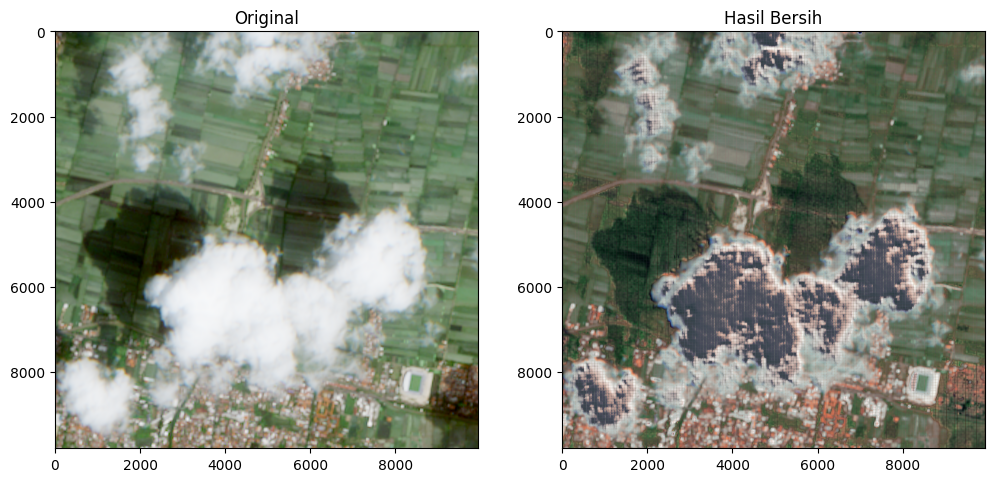

✅ Selesai.


In [47]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from PIL import Image, ImageOps
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
import scipy.ndimage
import shutil

# ==========================================
# KONFIGURASI
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16 
NUM_EPOCHS = 30
LR = 0.0002

WORK_DIR = './Training_Fixed_V7'
TARGET_DIR = os.path.join(WORK_DIR, 'targets')
INPUT_DIR = os.path.join(WORK_DIR, 'inputs')

# ==========================================
# 1. GENERATOR DATA (FIXED MATH)
# ==========================================
def generate_solid_cloud_mask(size):
    h, w = size
    noise = np.random.uniform(0, 1, (h, w))
    blobs = scipy.ndimage.gaussian_filter(noise, sigma=random.randint(6, 12))
    thresh = random.uniform(0.4, 0.6)
    mask = (blobs > thresh).astype(float)
    mask = scipy.ndimage.gaussian_filter(mask, sigma=1.0)
    return np.clip(mask, 0, 1)

def add_solid_clouds(img_pil):
    img_pil = img_pil.convert('RGB')
    w, h = img_pil.size
    img_np = np.array(img_pil).astype(float) # Shape: (H, W, 3)
    
    # 1. Masker Awan & Bayangan (H, W, 1)
    cloud_mask = generate_solid_cloud_mask((h, w))
    cloud_mask = cloud_mask[:, :, None] # Paksa jadi 3D biar bisa dikali dengan RGB
    
    shift_y, shift_x = random.randint(5, 10), random.randint(5, 10)
    shadow_mask = np.roll(cloud_mask, shift_y, axis=0)
    shadow_mask = np.roll(shadow_mask, shift_x, axis=1)
    shadow_mask[:shift_y, :] = 0
    shadow_mask[:, :shift_x] = 0
    
    # 2. Logika Bayangan (FIXED)
    # Area bayangan adalah yang ada Shadow tapi TIDAK ada Awan
    is_shadow = (shadow_mask > 0.5) & (cloud_mask < 0.5)
    
    # Buat Faktor Penggelap:
    # Jika is_shadow True -> faktor 0.4 (Gelap)
    # Jika is_shadow False -> faktor 1.0 (Tetap)
    shadow_factor = np.where(is_shadow, 0.4, 1.0)
    
    # Terapkan Faktor ke Gambar (Broadcasting akan otomatis menangani channel RGB)
    img_np = img_np * shadow_factor
    
    # 3. Terapkan Awan Putih
    # Gambar Asli * (1 - Mask) + Putih * Mask
    img_final = img_np * (1 - cloud_mask) + 255.0 * cloud_mask 
    
    return Image.fromarray(np.clip(img_final, 0, 255).astype(np.uint8))

def generate_dummy_data(count=400):
    print(f"   ⚠️ Membuat {count} Data Dummy (Simulasi Tanah & Awan)...")
    for i in range(count):
        # Background Tanah Palsu
        base_color = np.random.randint(50, 150, (64, 64, 3), dtype=np.uint8)
        texture = np.random.randint(-30, 30, (64, 64, 3), dtype=np.int16)
        land = np.clip(base_color + texture, 0, 255).astype(np.uint8)
        
        img = Image.fromarray(land)
        img.save(os.path.join(TARGET_DIR, f"dummy_{i}.jpg"))
        
        # Tambah Awan (Fungsi Baru yang Aman)
        cloudy = add_solid_clouds(img)
        cloudy.save(os.path.join(INPUT_DIR, f"dummy_{i}.jpg"))

def prepare_data():
    print("🔄 1. MENYIAPKAN DATA...")
    
    if os.path.exists(WORK_DIR):
        try: shutil.rmtree(WORK_DIR)
        except: pass
    os.makedirs(TARGET_DIR, exist_ok=True)
    os.makedirs(INPUT_DIR, exist_ok=True)

    # Cari EuroSat
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']
    source_files = []
    for ext in extensions:
        source_files.extend(glob(f'./EuroSat/**/{ext}', recursive=True))
        source_files.extend(glob(f'./EuroSat/{ext}'))

    # PROSES EUROSAT
    count_success = 0
    if len(source_files) > 0:
        print(f"   🔎 Mencoba memproses {len(source_files)} file EuroSat...")
        random.shuffle(source_files)
        
        for src_path in source_files[:800]:
            try:
                img = Image.open(src_path)
                if img.mode != 'RGB': img = img.convert('RGB')
                img = img.resize((64, 64))
                
                img.save(os.path.join(TARGET_DIR, f"{count_success}.jpg"))
                
                # Fungsi add_solid_clouds yang baru aman dari error dimensi
                cloudy = add_solid_clouds(img)
                cloudy.save(os.path.join(INPUT_DIR, f"{count_success}.jpg"))
                count_success += 1
            except: continue
    
    print(f"   ✅ Berhasil memproses {count_success} gambar asli.")

    if count_success < 50:
        print("   ⚠️ DATA ASLI KURANG. MENGAKTIFKAN DUMMY GENERATOR.")
        generate_dummy_data(count=600)
        
    if len(os.listdir(INPUT_DIR)) == 0:
        raise ValueError("FATAL: Masih gagal membuat data.")
        
    print("   📊 Data Siap! Lanjut Training.")

# ==========================================
# 2. MODEL (UNET)
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.conv3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)
        self.conv4 = DoubleConv(128, 256) 
        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv5 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv6 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.conv7 = DoubleConv(64, 32)
        self.out = nn.Conv2d(32, 3, 1)
    def forward(self, x):
        c1 = self.conv1(x); c2 = self.conv2(self.pool1(c1))
        c3 = self.conv3(self.pool2(c2)); bottleneck = self.conv4(self.pool3(c3))
        u1 = self.up1(bottleneck); u1 = torch.cat([u1, c3], dim=1); c5 = self.conv5(u1)
        u2 = self.up2(c5); u2 = torch.cat([u2, c2], dim=1); c6 = self.conv6(u2)
        u3 = self.up3(c6); u3 = torch.cat([u3, c1], dim=1); c7 = self.conv7(u3)
        return torch.sigmoid(self.out(c7))

# ==========================================
# 3. TRAINING
# ==========================================
class CloudDataset(Dataset):
    def __init__(self, root_input, root_target):
        self.files = sorted(os.listdir(root_input))
        self.root_input = root_input; self.root_target = root_target
        self.transform = transforms.Compose([transforms.ToTensor()])
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        name = self.files[idx]
        img_in = Image.open(os.path.join(self.root_input, name)).convert('RGB')
        img_ta = Image.open(os.path.join(self.root_target, name)).convert('RGB')
        return self.transform(img_in), self.transform(img_ta)

def train():
    print("\n🏋️ 2. MULAI TRAINING...")
    prepare_data()
    
    dataset = CloudDataset(INPUT_DIR, TARGET_DIR)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = UNet().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.L1Loss()
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for x, y in loop:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loop.set_postfix(loss=f"{loss.item():.4f}")
            
    return model

# ==========================================
# 4. INFERENCE
# ==========================================
def clean_image(image_path, model):
    print(f"\n✨ 3. MEMBERSIHKAN: {image_path}")
    if not os.path.exists(image_path): 
        print("❌ File gambar tidak ditemukan.")
        return

    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    tf = transforms.ToTensor()
    tensor = tf(img).unsqueeze(0).to(DEVICE)
    
    model.eval()
    tile_size = 64
    canvas = torch.zeros_like(tensor)
    
    with torch.no_grad():
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                tile = tensor[:, :, y:y+tile_size, x:x+tile_size]
                pad_h = tile_size - tile.shape[2]; pad_w = tile_size - tile.shape[3]
                if pad_h > 0 or pad_w > 0: tile = F.pad(tile, (0, pad_w, 0, pad_h))
                
                res = model(tile)
                
                if pad_h > 0 or pad_w > 0: res = res[:, :, :tile_size-pad_h, :tile_size-pad_w]
                canvas[:, :, y:y+tile_size, x:x+tile_size] = res

    result = canvas.squeeze(0).cpu().permute(1, 2, 0).numpy()
    
    # Simple Contrast
    img_res = Image.fromarray((np.clip(result, 0, 1) * 255).astype(np.uint8))
    img_res = ImageOps.autocontrast(img_res, cutoff=0) 

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(img_res); plt.title("Hasil Bersih")
    plt.show()
    
    img_res.save('Cloud_Removed_Final.png')
    print("✅ Selesai.")

if __name__ == "__main__":
    trained_model = train()
    clean_image('Cloud.png', trained_model)

# Checking GAN

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# 1. Load and Preprocess the image
img_path = 'Cloud.png'
raw_image = Image.open(img_path).convert('RGB')

C:\Users\Vulpolish\AppData\Roaming\Python\Python312\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (97244490 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [19]:
# Jalankan ini di GANs&Clouds.ipynb SETELAH training selesai
import torch

# Simpan otak model ke file bernama 'my_model.pth'
torch.save(generator.state_dict(), 'my_model.pth')
print("Model berhasil disimpan ke 'my_model.pth'. Silakan download file ini atau gunakan di notebook sebelah.")

Model berhasil disimpan ke 'my_model.pth'. Silakan download file ini atau gunakan di notebook sebelah.


In [20]:
# ==========================================
# 2. Setup Model & Processing Function
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Buat struktur model
generator = UNet().to(device)

# --- BAGIAN PENTING: MUAT BERAT (WEIGHTS) ---
try:
    # Memuat otak yang sudah disimpan tadi
    generator.load_state_dict(torch.load('my_model.pth', map_location=device))
    print("✅ Berhasil memuat model yang sudah dilatih!")
except FileNotFoundError:
    print("❌ ERROR: File 'my_model.pth' tidak ditemukan!")
    print("Kamu HARUS melakukan training di notebook sebelumnya dan menyimpannya dulu.")

generator.eval()

# ... (lanjutkan dengan fungsi clean_large_image kamu) ...

✅ Berhasil memuat model yang sudah dilatih!


UNet(
  (conv_1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=Tr

In [14]:
# ==========================================
# 1. Define the Architecture (From your Notebook)
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_1 = DoubleConv(3, 32)
        self.pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv_2 = DoubleConv(32, 64)
        self.pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv_3 = DoubleConv(64, 128)
        self.pool_3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv_4 = DoubleConv(128, 256)
        self.pool_4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv_5 = DoubleConv(256, 512)
        self.upconv_1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_6 = DoubleConv(512, 256)
        self.upconv_2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_7 = DoubleConv(256, 128)
        self.upconv_3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_8 = DoubleConv(128, 64)
        self.upconv_4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_9 = DoubleConv(64, 32)
        self.output = nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1)

    def forward(self, batch):
        c1 = self.conv_1(batch)
        c2 = self.conv_2(self.pool_1(c1))
        c3 = self.conv_3(self.pool_2(c2))
        c4 = self.conv_4(self.pool_3(c3))
        c5 = self.conv_5(self.pool_4(c4))
        c6 = self.conv_6(torch.cat([self.upconv_1(c5), c4], dim=1))
        c7 = self.conv_7(torch.cat([self.upconv_2(c6), c3], dim=1))
        c8 = self.conv_8(torch.cat([self.upconv_3(c7), c2], dim=1))
        c9 = self.conv_9(torch.cat([self.upconv_4(c8), c1], dim=1))
        return F.sigmoid(self.output(c9))


In [22]:
# ==========================================
# 2. Setup Model & Processing Function (DIPERBAIKI)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Buat wadah model kosong
generator = UNet().to(device)

# 2. ISI WADAH TERSEBUT DENGAN 'my_model.pth'
try:
    generator.load_state_dict(torch.load('my_model.pth', map_location=device))
    print("✅ BERHASIL: Model 'my_model.pth' telah dimuat!")
except FileNotFoundError:
    print("❌ ERROR: File 'my_model.pth' tidak ditemukan di folder ini.")
    print("Pastikan file tersebut ada di sebelah file notebook ini.")

generator.eval()

# --- Fungsi Processing (Tidak perlu diubah) ---
def clean_large_image(image_path, model, tile_size=64):
    try:
        img = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: File {image_path} not found.")
        return None

    w, h = img.size
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    output_canvas = torch.zeros_like(img_tensor)
    
    print(f"Processing {image_path} ({w}x{h})...")
    
    with torch.no_grad():
        for y in range(0, h, tile_size):
            for x in range(0, w, tile_size):
                tile = img_tensor[:, :, y:y+tile_size, x:x+tile_size]
                pad_h = tile_size - tile.shape[2]
                pad_w = tile_size - tile.shape[3]
                if pad_h > 0 or pad_w > 0:
                    tile = F.pad(tile, (0, pad_w, 0, pad_h))
                
                clean_tile = model(tile)
                
                if pad_h > 0 or pad_w > 0:
                    clean_tile = clean_tile[:, :, :tile_size-pad_h, :tile_size-pad_w]
                
                output_canvas[:, :, y:y+tile_size, x:x+tile_size] = clean_tile

    return output_canvas.squeeze(0).cpu().permute(1, 2, 0).numpy()

# --- Cek Status Otak ---
check_brain_status(generator)

✅ BERHASIL: Model 'my_model.pth' telah dimuat!
Weight Mean: -0.001467
Weight Spread (Std): 0.110093

DIAGNOSIS: 🟢 TRAINED (Likely)
The weights show structure. If output is still gray, check the input normalization.


In [17]:
def check_brain_status(model):
    # Check the very first layer's weights
    first_layer_weights = model.conv_1.double_conv[0].weight.data
    
    # Calculate the standard deviation (spread) of the weights
    std = first_layer_weights.std().item()
    mean = first_layer_weights.mean().item()
    
    print(f"Weight Mean: {mean:.6f}")
    print(f"Weight Spread (Std): {std:.6f}")
    
    if std < 0.05:
        print("\nDIAGNOSIS: 🔴 EMPTY / UNTRAINED")
        print("Your weights are too uniform. The model has not learned anything.")
        print("Solution: You MUST run the training loop cell before removing clouds.")
    else:
        print("\nDIAGNOSIS: 🟢 TRAINED (Likely)")
        print("The weights show structure. If output is still gray, check the input normalization.")

check_brain_status(generator)

Weight Mean: -0.001467
Weight Spread (Std): 0.110093

DIAGNOSIS: 🟢 TRAINED (Likely)
The weights show structure. If output is still gray, check the input normalization.


Processing Cloud.png (9930x9793)...


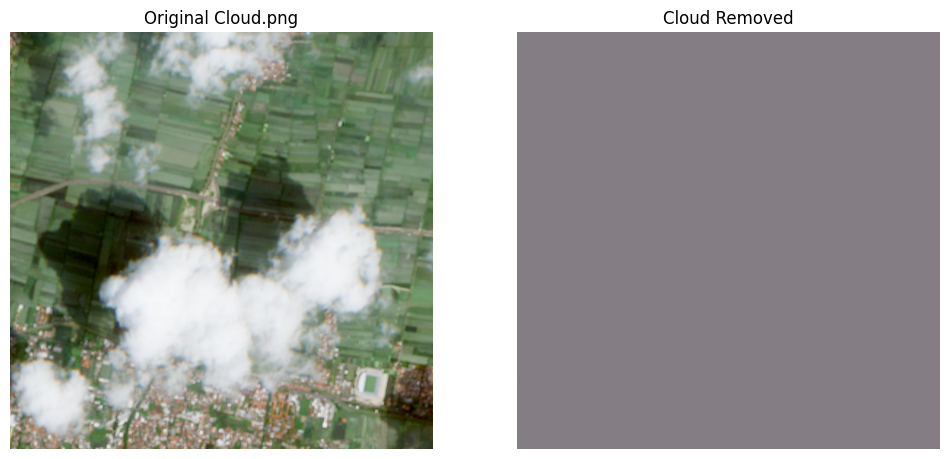

Saved result to Cloud_Removed.png


In [23]:
# ==========================================
# 3. Run on 'Cloud.png'
# ==========================================
result = clean_large_image('Cloud.png', generator)

if result is not None:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Cloud.png")
    plt.imshow(Image.open('Cloud.png'))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Cloud Removed")
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    # Save the result
    plt.imsave('Cloud_Removed.png', result)
    print("Saved result to Cloud_Removed.png")

In [24]:
import torch

def cek_isi_otak(model_path):
    try:
        # Load weights
        state_dict = torch.load(model_path, map_location='cpu')
        
        # Ambil sampel satu layer (conv_1)
        first_layer = state_dict['conv_1.double_conv.0.weight']
        
        # Hitung statistik
        std = first_layer.std().item()
        mean = first_layer.mean().item()
        
        print(f"📊 Statistik Model '{model_path}':")
        print(f"   - Rata-rata bobot: {mean:.5f}")
        print(f"   - Variasi (Std):   {std:.5f}")
        
        if std < 0.15: # Ambang batas bobot random inisialisasi
            print("\n❌ KESIMPULAN: MODEL KOSONG / BELUM DILATIH")
            print("   Model ini hanya berisi angka acak (random noise).")
            print("   Penyebab: Training di file sebelah tidak berjalan semestinya.")
        else:
            print("\n✅ KESIMPULAN: Model berisi pengetahuan (Trained).")
            
    except Exception as e:
        print(f"Error membaca file: {e}")

cek_isi_otak('my_model.pth')

📊 Statistik Model 'my_model.pth':
   - Rata-rata bobot: -0.00147
   - Variasi (Std):   0.11009

❌ KESIMPULAN: MODEL KOSONG / BELUM DILATIH
   Model ini hanya berisi angka acak (random noise).
   Penyebab: Training di file sebelah tidak berjalan semestinya.


# Test

In [6]:
import cv2
import pandas as pd
import numpy as np
from PIL import Image

In [7]:

# 1. Load gambar
# Menggunakan OpenCV untuk membaca gambar
img = cv2.imread('Sample.png')

# OpenCV membaca dalam format BGR, kita ubah ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Dapatkan dimensi gambar
height, width, channels = img_rgb.shape
print(f"Dimensi Gambar: {width}x{height} piksel")

# 3. Ubah matriks gambar menjadi array 2D (Piksel x Warna)
pixels = img_rgb.reshape(-1, 3)

# 4. Buat koordinat X dan Y untuk setiap piksel (opsional, berguna untuk mapping)
x, y = np.meshgrid(np.arange(width), np.arange(height))
x_coords = x.flatten()
y_coords = y.flatten()

# 5. Masukkan ke dalam Pandas DataFrame
df = pd.DataFrame({
    'X': x_coords,
    'Y': y_coords,
    'Red': pixels[:, 0],
    'Green': pixels[:, 1],
    'Blue': pixels[:, 2]
})

# 6. Tampilkan 5 data teratas
print("Pratinjau Variabel Penelitian:")
print(df.head())

# 7. Ekspor ke CSV untuk analisis lebih lanjut
df.to_csv('data_pixel_satelit.csv', index=False)
print("\nFile 'data_pixel_satelit.csv' berhasil dibuat!")

Dimensi Gambar: 9930x10308 piksel
Pratinjau Variabel Penelitian:
   X  Y  Red  Green  Blue
0  0  0  154    163   154
1  1  0  155    163   154
2  2  0  155    163   154
3  3  0  155    163   155
4  4  0  155    164   155

File 'data_pixel_satelit.csv' berhasil dibuat!


In [10]:
df

,X,Y,Red,Green,Blue
0,0,0,154,163,154
1,1,0,155,163,154
2,2,0,155,163,154
3,3,0,155,163,155
4,4,0,155,164,155
...,...,...,...,...,...
102358435,9925,10307,138,155,126
102358436,9926,10307,138,155,126
102358437,9927,10307,138,155,127
102358438,9928,10307,138,156,127
